# Project 4: Classification with Logistic Regression, Decision Tree, Random Forest and XGBoost

**Authors:** Abigail Keegan, Michelle Ng Du

**Course:** CS 667 Practical Data Science, Pace University

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import eli5

from lime import lime_tabular
import shap

from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score, precision_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split

/home/abigailkeegan/Practical-Data-Science-Projects/project-4-heart-failure-classification/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Perform Exploratory Data Analysis (EDA) / indicate how features correlate among themselves, with emphasis on the target/label.

In [2]:
# Load heart failure dataset and summaries
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
print(df.info())
print(df.describe())
# Check for missingness
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
None
              age     an

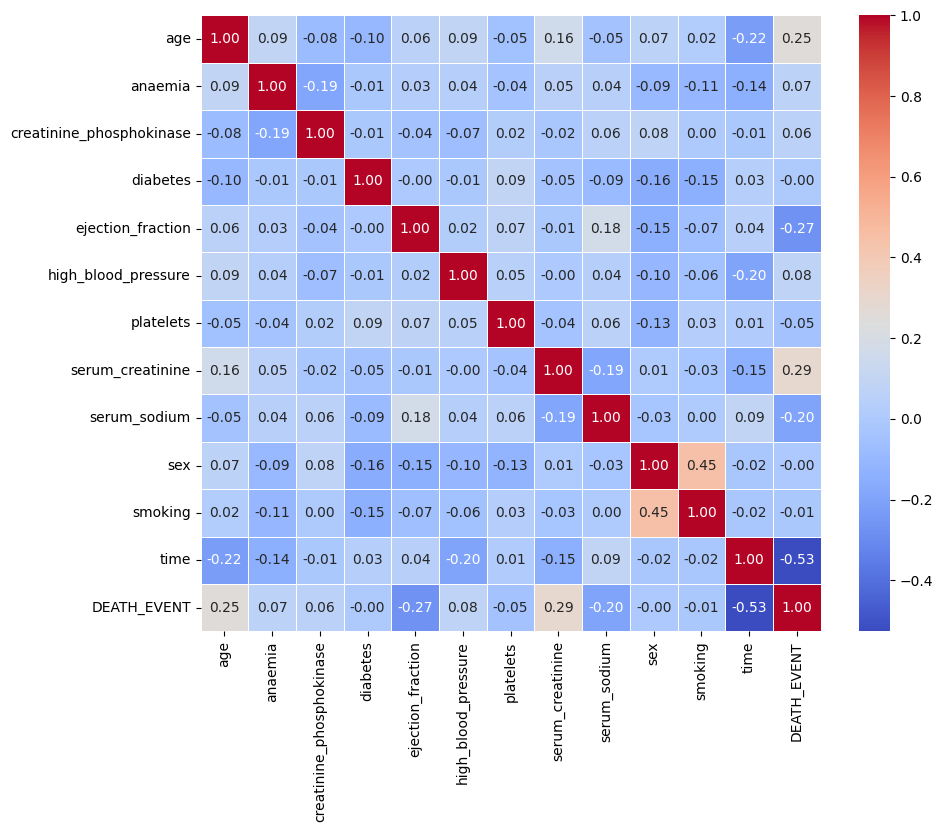

In [3]:
# Correlation heatmap
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.show()

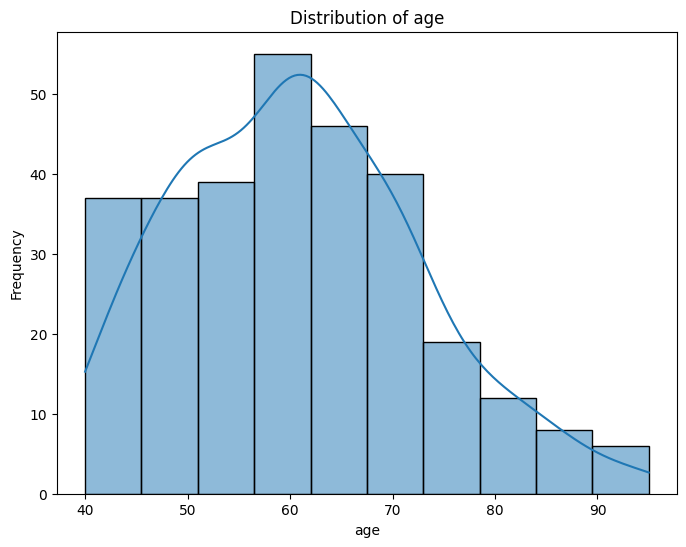

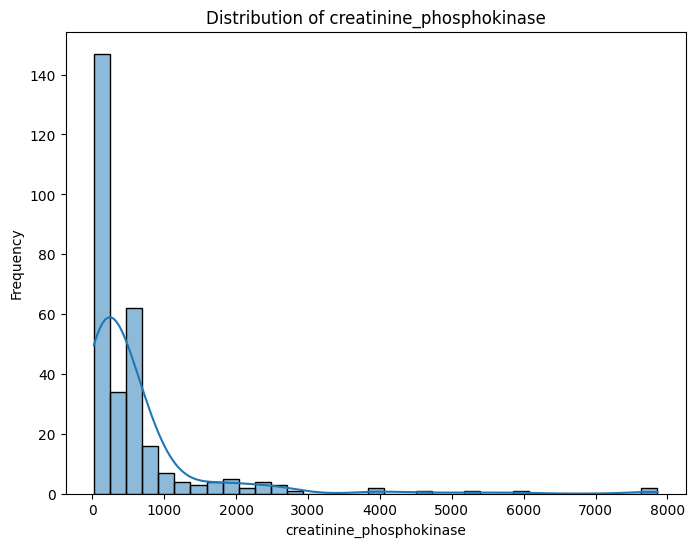

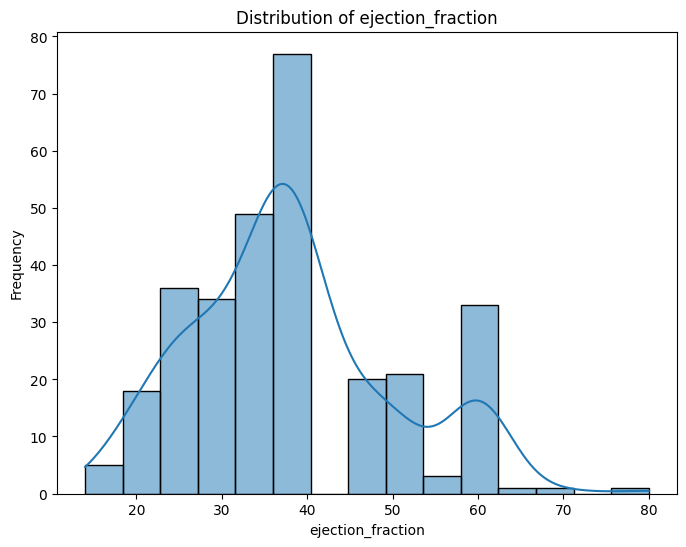

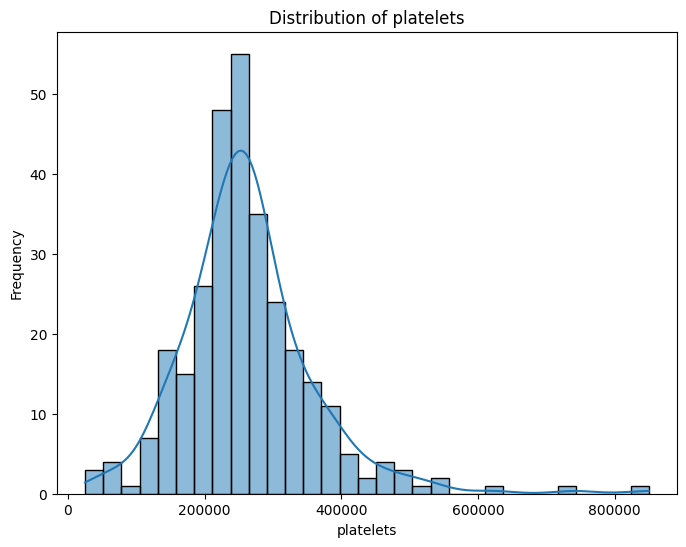

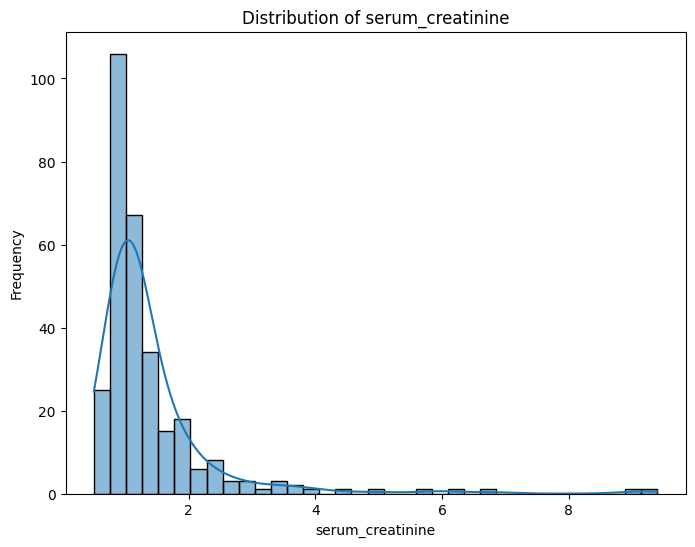

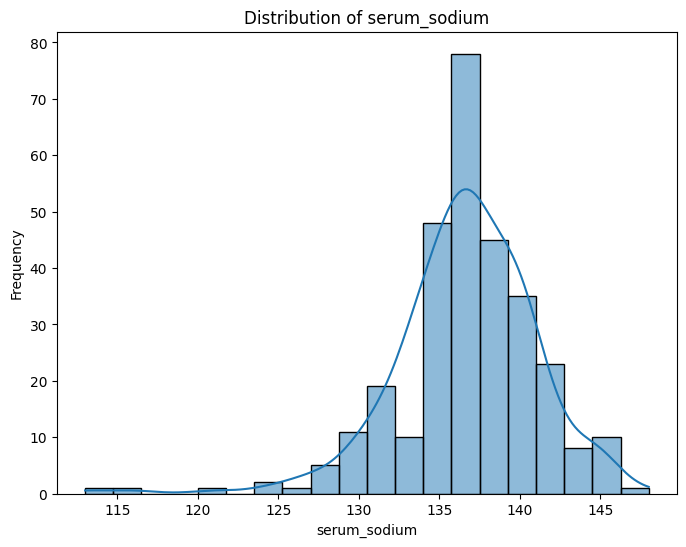

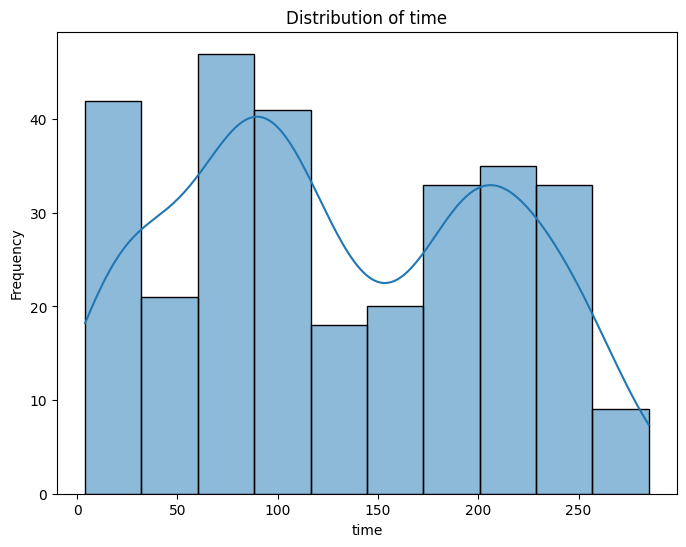

In [4]:
# Histograms of quantitative variables
quant_col = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
for col in quant_col:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

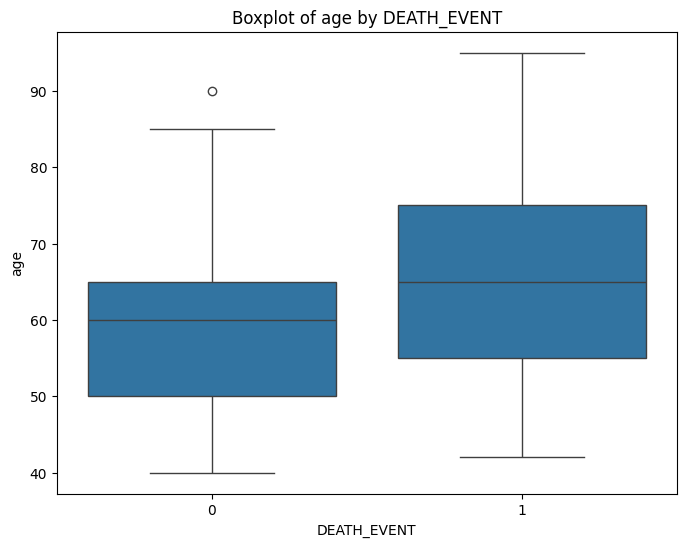

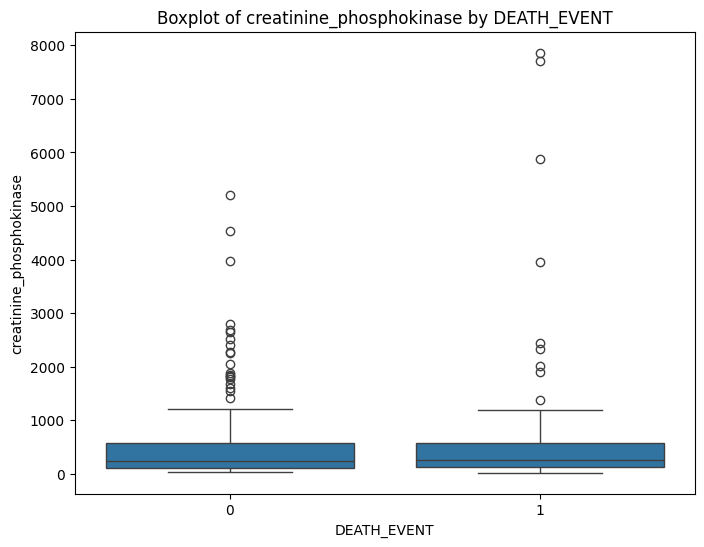

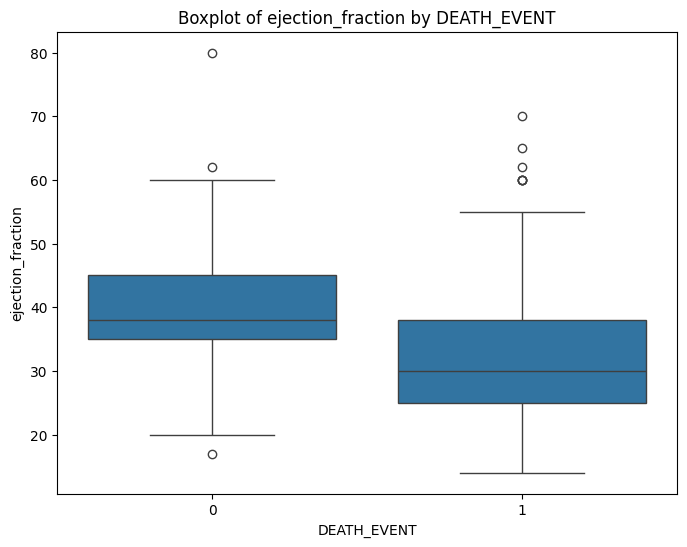

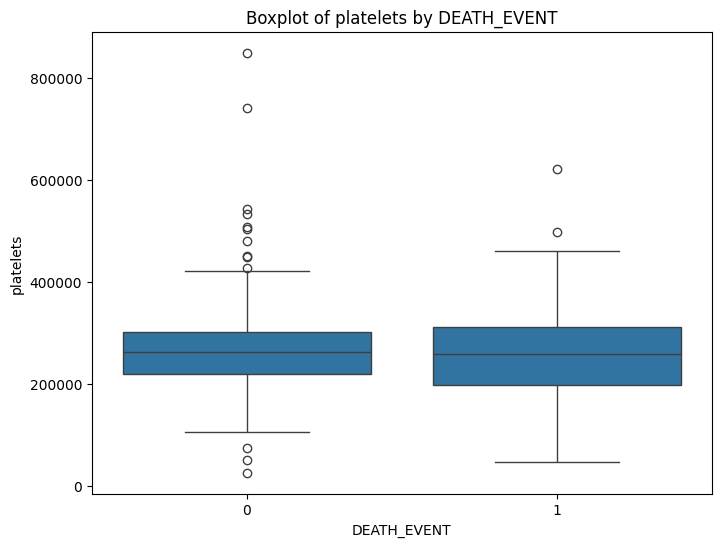

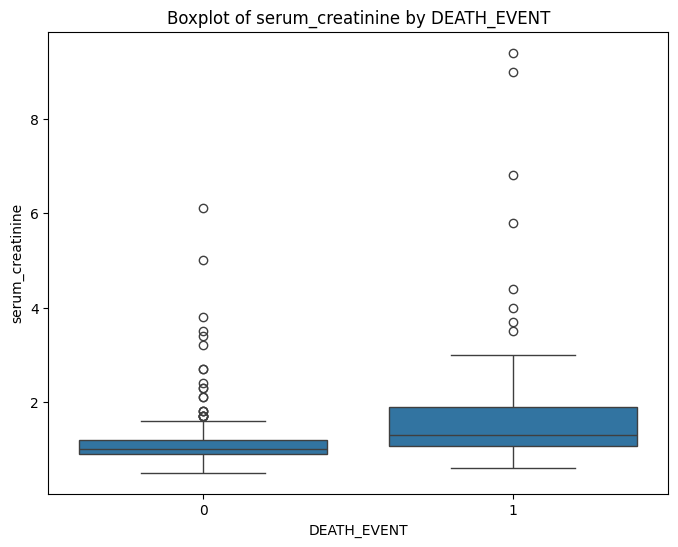

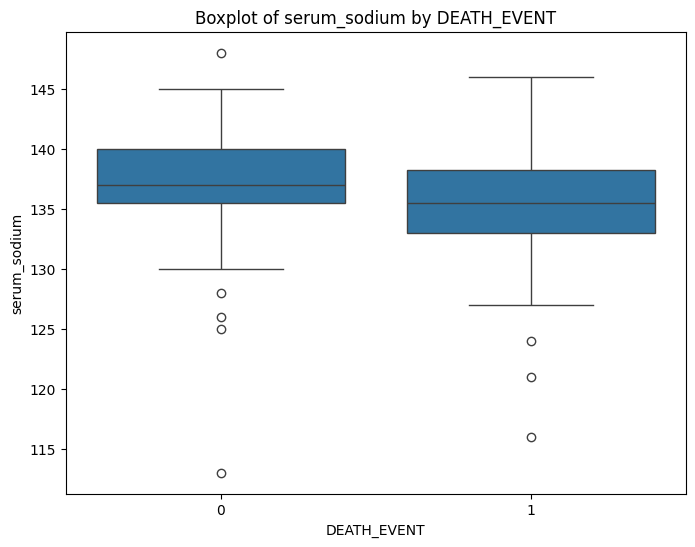

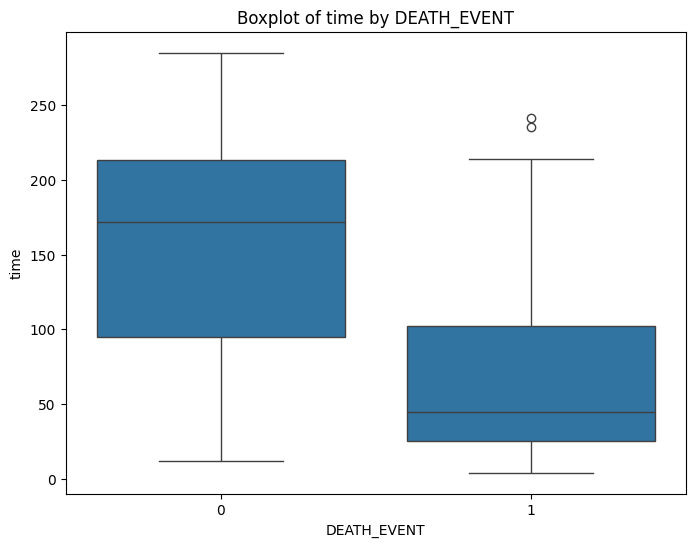

In [5]:
# Boxplots of quantitative variables
for col in quant_col:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x='DEATH_EVENT', y=col, data=df)
  plt.title(f'Boxplot of {col} by DEATH_EVENT')
  plt.xlabel('DEATH_EVENT')
  plt.ylabel(col)
  plt.show()

In [6]:
# Copy of df for changes
n_df = df.copy()

#### EDA Interpretation

The dataset has 299 patient records. Roughly 2 out of 3 patients survived, so the classes are somewhat unbalanced. This means raw accuracy can be misleading as a metric.

The most useful features for predicting death are `time` (how long the patient was monitored), `serum_creatinine` (a marker of kidney function), and `ejection_fraction` (how well the heart pumps blood). Patients monitored for longer tended to survive, patients with high creatinine were more likely to die, and patients with higher ejection fractions were more likely to survive. Features like `smoking`, `diabetes`, and `high_blood_pressure` had very weak relationships when looked at individually.

Some features like `creatinine_phosphokinase` and `platelets` had heavily skewed distributions, which is why we scale the data before modeling in the next steps.

2. Apply Machine Learning Modeling on the dataset using all the above 4 algorithms.
Tune (hyper-parameter tuning) each model by calling the GridSearchCV method.
Indicate which combination of Hyperparameters produces the best result.
Note: Use accuracy and AUC-ROC metrics when evaluating your models.

In [7]:
# Standardize quantitative features to address skewed distributions
scaler = preprocessing.StandardScaler()
n_df[quant_col] = scaler.fit_transform(n_df[quant_col])

In [8]:
# Drop target variable
X, y = n_df.drop('DEATH_EVENT', axis=1), n_df['DEATH_EVENT']
# Split 80 / 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Stratified k-fold for cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
# Logistic Regression with GridSearch
lr = LogisticRegression()
param_grid = [
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    },
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs', 'saga']
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.2, 0.5, 0.8]
    }
]

lr_grid = GridSearchCV(estimator=lr, param_grid=param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

lr_best = lr_grid.best_estimator_
lr_param = lr_grid.best_params_
lr_score = lr_grid.best_score_

print(f'Best Logistic Regression Params: {lr_param}')
print(f'Best Logistic Regression Score: {lr_score}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Logistic Regression Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Logistic Regression Score: 0.9056667515491045


In [11]:
# Decision Tree with GridSearch
dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
dt_grid.fit(X_train, y_train)

dt_best = dt_grid.best_estimator_
dt_param = dt_grid.best_params_
dt_score = dt_grid.best_score_

print(f'Best Decision Tree Params: {dt_param}')
print(f'Best Decision Tree Score: {dt_score}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Decision Tree Score: 0.8845539427892369


In [12]:
# Random Forest with GridSearch
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(estimator=rf, param_grid=rf_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_param = rf_grid.best_params_
rf_score = rf_grid.best_score_

print(f'Best Random Forest Params: {rf_param}')
print(f'Best Random Forest Score: {rf_score}')


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest Score: 0.9452958152958153


In [13]:
# XGBoost with GridSearch
xgb = XGBClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xg_grid = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
xg_grid.fit(X_train, y_train)

xg_best = xg_grid.best_estimator_
xg_param = xg_grid.best_params_
xg_score = xg_grid.best_score_

print(f'Best XGBoost Params: {xg_param}')
print(f'Best XGBoost Score: {xg_score}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost Score: 0.9370647653000596


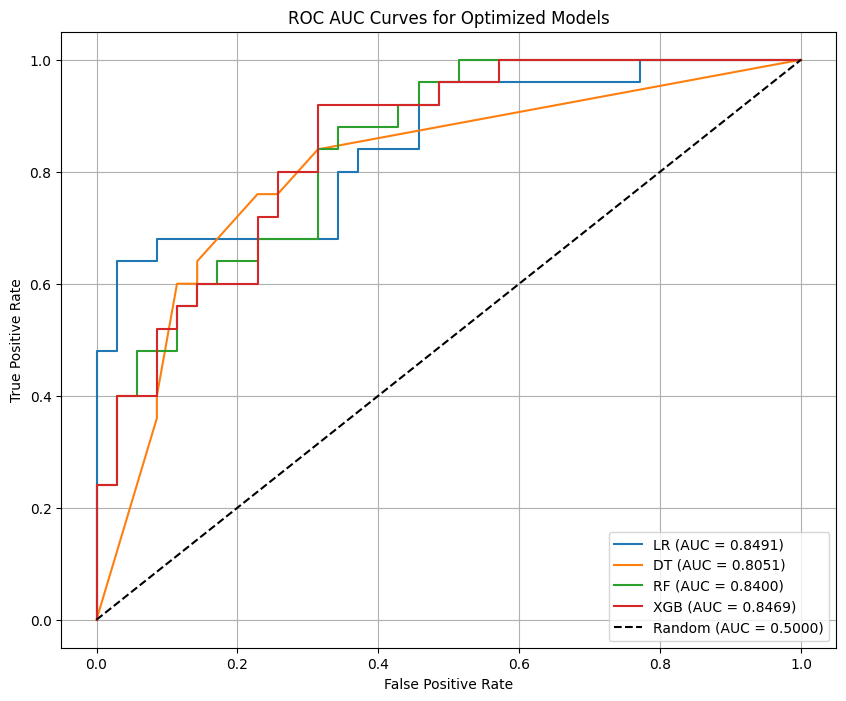

In [14]:
# Plot ROC-AUC curves for all four models
models = {'LR' : lr_best, 'DT' : dt_best, 'RF' : rf_best, 'XGB': xg_best,}
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curves for Optimized Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Modeling and Tuning Interpretation

GridSearchCV with 5-fold stratified cross-validation identified the following best hyperparameter combinations:

- **Logistic Regression**: heavy regularization (C=0.01), which keeps the model simple and prevents overfitting on this small dataset. Cross-validation AUC: 0.9057. Test AUC: 0.8491.
- **Decision Tree**: max depth of 5, minimum 4 samples per leaf, gini criterion. Cross-validation AUC: 0.8846. Test AUC: 0.8051.
- **Random Forest**: 200 trees with depth capped at 5. Cross-validation AUC: 0.9453. Test AUC: 0.8400.
- **XGBoost**: slow learning rate (0.01) with 200 trees at depth 7 and 80% subsampling. Cross-validation AUC: 0.9371. Test AUC: 0.8469.

Random Forest and XGBoost achieved the highest cross-validation AUC scores. Across all four models, cross-validation AUC was 5 to 10 percentage points higher than test AUC, which is consistent with what to expect from a small dataset (299 patients) where a single 80/20 split is sensitive to which specific patients land in the test set.

3.


*  Use the 'eli5' library to interpret the "white box" model of Logistic Regression.
Apply 'eli5' to visualize the weights associated with each feature.
Use 'eli5' to explain specific predictions, pick a row in the test data with negative label
and one with positive.

*   Use the 'eli5' library to interpret the "white box" model of Decision Tree.
Apply 'eli5' to list the feature importance ordered by the highest value.
Get an explanation for a given prediction, one positive and one negative. This will
calculate the contribution of each feature in the prediction. The explanation for a single
prediction is calculated by following the decision path in the tree, and adding up
contribution of each feature from each node crossed into the overall probability predicted.
* eli5 can also be used to explain black box models, but we will use LIME and SHAP for
our two last models instead.


In [15]:
# eli5 for Logistic Regression
expl = eli5.explain_weights(lr_best, feature_names=list(X_train.columns))
# eli5 for LR as plain text
print(eli5.format_as_text(expl))

Explained as: linear model

Features with largest coefficients.
Caveats:
1. Be careful with features which are not
   independent - weights don't show their importance.
2. If scale of input features is different then scale of coefficients
   will also be different, making direct comparison between coefficient values
   incorrect.
3. Depending on regularization, rare features sometimes may have high
   coefficients; this doesn't mean they contribute much to the
   classification result for most examples.

y=1 top features
Weight  Feature                 
------  ------------------------
+0.200  serum_creatinine        
+0.177  age                     
+0.028  creatinine_phosphokinase
+0.015  anaemia                 
+0.015  high_blood_pressure     
+0.009  diabetes                
-0.014  smoking                 
-0.030  platelets               
-0.031  sex                     
-0.102  serum_sodium            
-0.178  ejection_fraction       
-0.371  time                    
-0.911  <BI

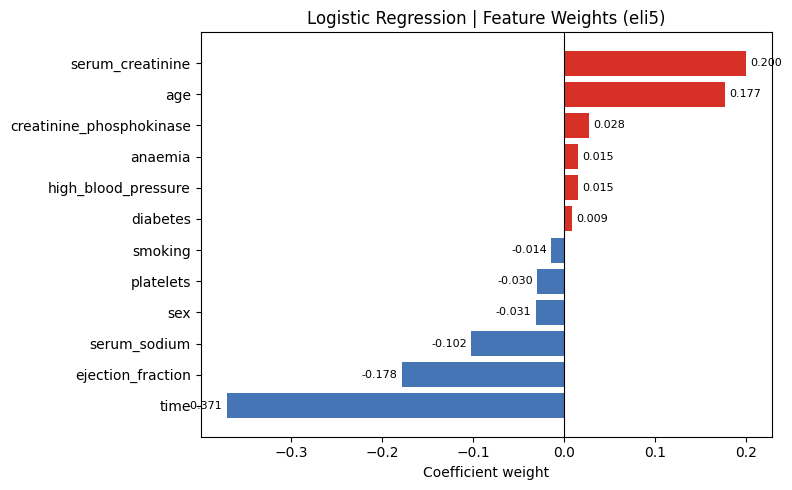

In [16]:
# eli5 for LR as a bar chart
weights_dict = {
    fw.feature: fw.weight
    for fw in expl.targets[0].feature_weights.pos + expl.targets[0].feature_weights.neg
    if fw.feature != '<BIAS>'
}
features = list(weights_dict.keys())
weights  = list(weights_dict.values())
order    = np.argsort(weights)
features = [features[i] for i in order]
weights  = [weights[i]  for i in order]
colors   = ['#d73027' if w > 0 else '#4575b4' for w in weights]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(features, weights, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient weight')
ax.set_title('Logistic Regression | Feature Weights (eli5)')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

=== Negative sample (index=281, true label=0) ===
Explained as: linear model
y=0 (probability=0.748, score=-1.090) top features
Contribution  Feature                 
------------  ------------------------
      +0.911  <BIAS>                  
      +0.573  time                    
      +0.031  sex                     
      +0.029  ejection_fraction       
      +0.014  smoking                 
      -0.000  creatinine_phosphokinase
      -0.015  serum_sodium            
      -0.065  platelets               
      -0.136  age                     
      -0.253  serum_creatinine        


=== Positive sample (index=164, true label=1) ===
Explained as: linear model
y=0 (probability=0.754, score=-1.122) top features
Contribution  Feature                 
------------  ------------------------
      +0.911  <BIAS>                  
      +0.236  age                     
      +0.057  serum_creatinine        
      +0.055  serum_sodium            
      +0.031  sex                     
 

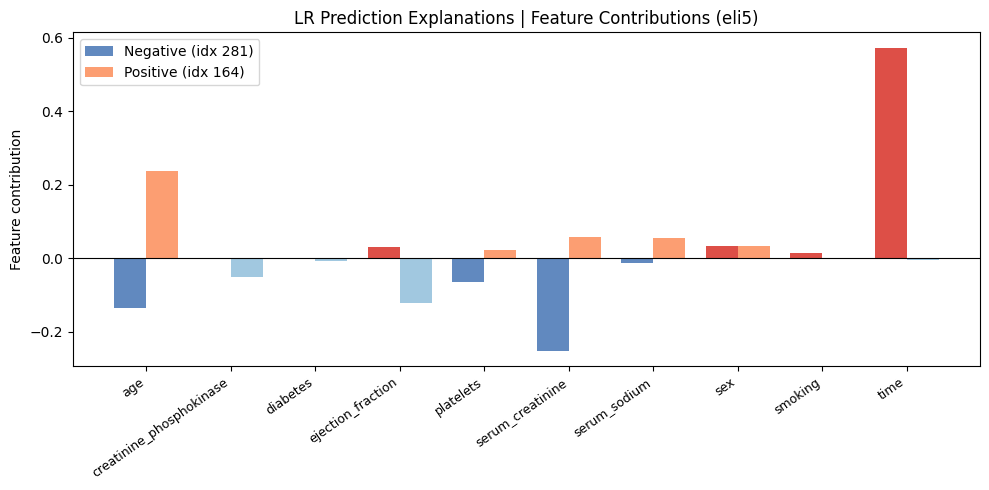

In [17]:
# individual LR predictions (plain text + grouped bar chart)

neg_idx = y_test[y_test == 0].index[0]
pos_idx = y_test[y_test == 1].index[0]
neg_row = X_test.loc[[neg_idx]]
pos_row = X_test.loc[[pos_idx]]

def eli5_to_dict(expl):
    """Extract {feature: contribution} from an eli5 prediction explanation."""
    fw = expl.targets[0].feature_weights
    result = {}
    for item in fw.pos + fw.neg:
        if item.feature != '<BIAS>':
            result[item.feature] = item.weight
    return result

expl_neg = eli5.explain_prediction(lr_best, neg_row.iloc[0], feature_names=list(X_train.columns))
expl_pos = eli5.explain_prediction(lr_best, pos_row.iloc[0], feature_names=list(X_train.columns))

print(f"=== Negative sample (index={neg_idx}, true label={y_test[neg_idx]}) ===")
print(eli5.format_as_text(expl_neg))
print()
print(f"=== Positive sample (index={pos_idx}, true label={y_test[pos_idx]}) ===")
print(eli5.format_as_text(expl_pos))

neg_dict = eli5_to_dict(expl_neg)
pos_dict = eli5_to_dict(expl_pos)
all_feats = sorted(set(neg_dict) | set(pos_dict))
neg_vals  = [neg_dict.get(f, 0) for f in all_feats]
pos_vals  = [pos_dict.get(f, 0) for f in all_feats]

x   = np.arange(len(all_feats))
w   = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, neg_vals, w, label=f'Negative (idx {neg_idx})',
       color=['#d73027' if v > 0 else '#4575b4' for v in neg_vals], alpha=0.85)
ax.bar(x + w/2, pos_vals, w, label=f'Positive (idx {pos_idx})',
       color=['#fc8d59' if v > 0 else '#91bfdb' for v in pos_vals], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_feats, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Feature contribution')
ax.set_title('LR Prediction Explanations | Feature Contributions (eli5)')
ax.legend()
plt.tight_layout()
plt.show()

#### eli5: Logistic Regression

What the model learned overall:
* The two features most associated with survival were `time` and `ejection_fraction`. Longer monitoring periods and stronger heart pumping both pointed toward survival.
* The feature most associated with death was `serum_creatinine`. High creatinine signals kidney problems, which are dangerous in heart failure patients. Most other features had small weights and contributed little.

**Patient Survival**: The model correctly predicted survival with 75% confidence. The main features pushing toward survival were a long follow-up period and a normal ejection fraction.

**Patient Death**: The model incorrectly predicted survival with 75% confidence. High `serum_creatinine` and low `ejection_fraction` pointed toward death, but `age` and `serum_sodium` pushed the other way and outweighed them. This highlights a key weakness of logistic regression on this dataset.


Explained as: decision tree

Decision tree feature importances; values are numbers 0 <= x <= 1;
all values sum to 1.

0.6679  time
0.2117  serum_creatinine
0.0452  ejection_fraction
0.0239  creatinine_phosphokinase
0.0180  serum_sodium
0.0171  platelets
0.0162  age
     0  smoking
     0  sex
     0  high_blood_pressure
     0  diabetes
     0  anaemia

time <= -0.733  (25.1%)
    serum_sodium <= -0.028  (13.0%)
        ejection_fraction <= 0.797  (10.5%)  ---> 1.000
        ejection_fraction > 0.797  (2.5%)  ---> 0.667
    serum_sodium > -0.028  (12.1%)
        time <= -1.055  (9.2%)
            creatinine_phosphokinase <= -0.495  (1.7%)  ---> 0.500
            creatinine_phosphokinase > -0.495  (7.5%)
                serum_creatinine <= 0.296  (5.9%)  ---> 1.000
                serum_creatinine > 0.296  (1.7%)  ---> 0.750
        time > -1.055  (2.9%)  ---> 0.286
time > -0.733  (74.9%)
    serum_creatinine <= 0.408  (67.4%)
        ejection_fraction <= -0.473  (14.6%)
            ser

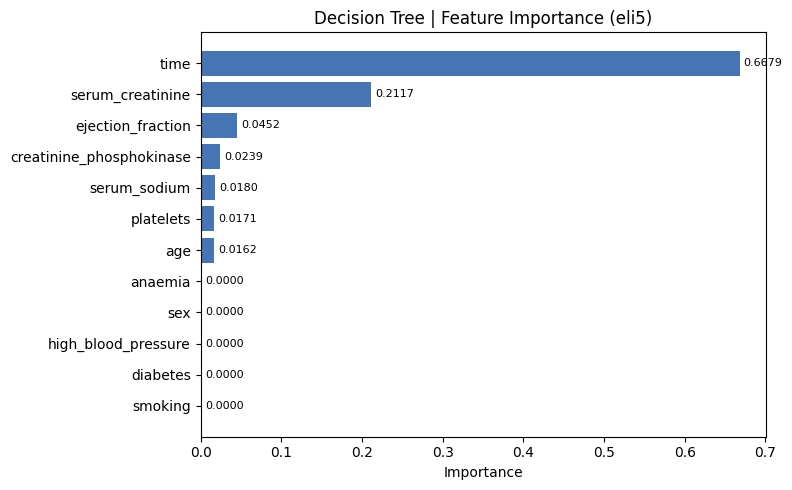

In [18]:
# eli5 Decision Tree feature importance (plain text + bar chart)

expl_dt = eli5.explain_weights(dt_best, feature_names=list(X_train.columns))
print(eli5.format_as_text(expl_dt))

importances = {
    fw.feature: fw.weight
    for fw in expl_dt.feature_importances.importances
    if fw.feature != '<BIAS>'
}
features = list(importances.keys())
values   = list(importances.values())
order    = np.argsort(values)
features = [features[i] for i in order]
values   = [values[i]   for i in order]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(features, values, color='#4575b4')
ax.set_xlabel('Importance')
ax.set_title('Decision Tree | Feature Importance (eli5)')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
plt.tight_layout()
plt.show()

=== Negative sample (index=281, true label=0) ===
Explained as: decision path

Features with largest coefficients.

Feature weights are calculated by following decision paths in trees
of an ensemble (or a single tree for DecisionTreeClassifier).
Each node of the tree has an output score, and contribution of a feature
on the decision path is how much the score changes from parent to child.
Weights of all features sum to the output score or proba of the estimator.

Caveats:
1. Feature weights just show if the feature contributed positively or
   negatively to the final score, and does not show how increasing or
   decreasing the feature value will change the prediction.
2. In some cases, feature weight can be close to zero for an important feature.
   For example, in a single tree that computes XOR function, the feature at the
   top of the tree will have zero weight because expected scores for both
   branches are equal, so decision at the top feature does not change the
   expected sco

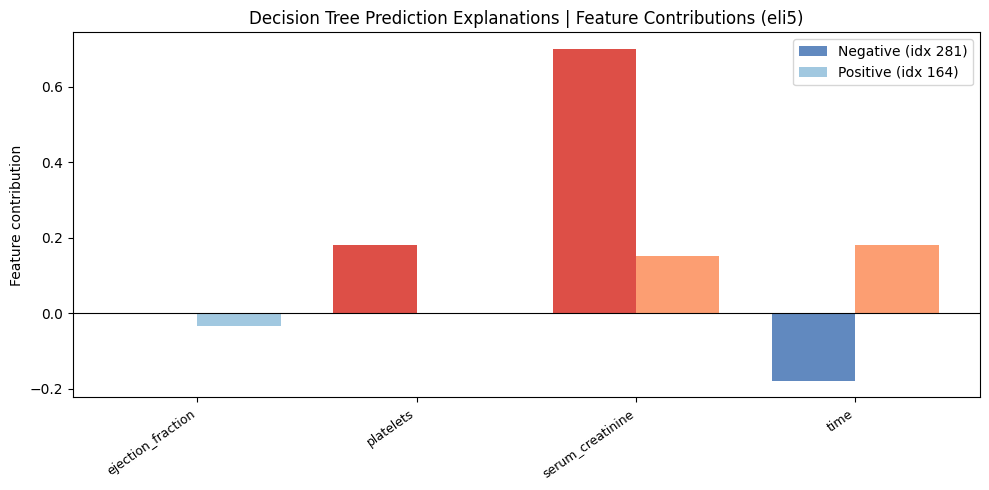

In [19]:
# eli5 explain individual DT predictions (plain text + grouped bar chart)

def eli5_dt_contributions(expl):
    """Extract {feature: contribution} from a DT prediction explanation."""
    result = {}
    fw = expl.targets[0].feature_weights
    for item in fw.pos + fw.neg:
        if item.feature != '<BIAS>':
            result[item.feature] = item.weight
    return result

expl_dt_neg = eli5.explain_prediction(dt_best, neg_row.iloc[0], feature_names=list(X_train.columns))
expl_dt_pos = eli5.explain_prediction(dt_best, pos_row.iloc[0], feature_names=list(X_train.columns))

print(f"=== Negative sample (index={neg_idx}, true label={y_test[neg_idx]}) ===")
print(eli5.format_as_text(expl_dt_neg))
print()
print(f"=== Positive sample (index={pos_idx}, true label={y_test[pos_idx]}) ===")
print(eli5.format_as_text(expl_dt_pos))


neg_dict = eli5_dt_contributions(expl_dt_neg)
pos_dict = eli5_dt_contributions(expl_dt_pos)
all_feats = sorted(set(neg_dict) | set(pos_dict))
neg_vals  = [neg_dict.get(f, 0) for f in all_feats]
pos_vals  = [pos_dict.get(f, 0) for f in all_feats]

x   = np.arange(len(all_feats))
w   = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, neg_vals, w, label=f'Negative (idx {neg_idx})',
       color=['#d73027' if v > 0 else '#4575b4' for v in neg_vals], alpha=0.85)
ax.bar(x + w/2, pos_vals, w, label=f'Positive (idx {pos_idx})',
       color=['#fc8d59' if v > 0 else '#91bfdb' for v in pos_vals], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_feats, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Feature contribution')
ax.set_title('Decision Tree Prediction Explanations | Feature Contributions (eli5)')
ax.legend()
plt.tight_layout()
plt.show()

#### eli5: Decision Tree

**Feature importance**: The decision tree relied almost entirely on two features. `time` accounted for 67% of all splits, and `serum_creatinine` accounted for another 23%. Everything else played a minor role. Features like `smoking`, `sex`, `high_blood_pressure`, `diabetes`, and `anaemia` were never used by the tree at all.

**Patient Survival**: The tree incorrectly predicted death with 100% certainty. `serum_creatinine` was the dominant driver (+0.701), followed by `platelets` (+0.182), both pushing toward a death prediction. `time` pushed slightly against it (-0.180) but was not enough to change the outcome.

**Patient Death**: The tree incorrectly predicted survival with 100% certainty. `time` (+0.180) and `serum_creatinine` (+0.152) both fell in ranges the tree associates with survival, while `ejection_fraction` had a small negative effect. This is consistent with the low AUC-ROC score for the Decision Tree. It struggles with individual predictions despite reasonable overall accuracy.

LIME for black box models instructions:
* Use LIME to explain both the Random Forest and the XGBoost models.
Create a LIME explainer by using the LimeTabularExplainer method, the main
explainer to use for tabular data.
* LIME fits a linear model on a local shuffled dataset. Access the coefficients, the intercept and the R of the linear model, for both model interpretability.
* Note: If R2 is low, the linear model that LIME fits isn't a great approximation to your
model, which means you should not rely too much on the explanation it provides.

In [20]:
# Initialize LIME explainer for training data
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=['Survived (0)', 'Died (1)'],
    mode='classification',
    random_state=42
)

=== RF — Negative Sample ===
Intercept  : 0.3116
Coefficients (feature, weight):
  serum_creatinine > 0.01                        +0.2035
  time > 0.97                                    -0.1643
  age > 0.73                                     +0.0830
  -0.01 < ejection_fraction <= 0.59              -0.0513
  platelets <= -0.52                             +0.0348
  -0.35 < creatinine_phosphokinase <= 0.00       +0.0204
  0.00 < sex <= 1.00                             -0.0186
  -0.60 < serum_sodium <= 0.09                   -0.0147
  high_blood_pressure <= 0.00                    -0.0118
  diabetes <= 0.00                               +0.0060
  anaemia <= 0.00                                +0.0040
  0.00 < smoking <= 1.00                         -0.0025
R² of local linear model: 0.2728


/home/abigailkeegan/Practical-Data-Science-Projects/project-4-heart-failure-classification/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


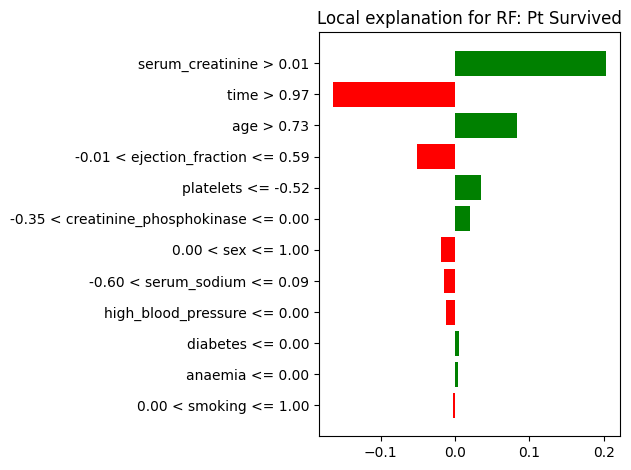

In [21]:
# Lime Explainer for Random Forest negative outcome (patient survives)
rf_exp_neg = lime_explainer.explain_instance(
    neg_row.values[0],
    rf_best.predict_proba,
    num_features=len(X_train.columns)
)
print("=== RF — Negative Sample ===")
print(f"Intercept  : {rf_exp_neg.intercept[1]:.4f}")
print(f"Coefficients (feature, weight):")
for feat, weight in rf_exp_neg.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")
print(f"R² of local linear model: {rf_exp_neg.score:.4f}")
rf_exp_neg.as_pyplot_figure()
plt.title("Local explanation for RF: Pt Survived")
plt.tight_layout()
plt.show()

/home/abigailkeegan/Practical-Data-Science-Projects/project-4-heart-failure-classification/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


=== RF — Positive Sample ===
Intercept  : 0.3719
Coefficients (feature, weight):
  -0.15 < time <= 0.97                           -0.1352
  ejection_fraction <= -0.68                     +0.1122
  -0.48 < serum_creatinine <= -0.28              -0.0801
  age <= -0.74                                   -0.0485
  0.00 < sex <= 1.00                             -0.0191
  0.09 < serum_sodium <= 0.54                    -0.0188
  high_blood_pressure <= 0.00                    +0.0170
  anaemia <= 0.00                                -0.0070
  platelets > 0.41                               -0.0043
  0.00 < diabetes <= 1.00                        -0.0041
  smoking <= 0.00                                -0.0021
  creatinine_phosphokinase > 0.00                +0.0004
R² of local linear model: 0.1520


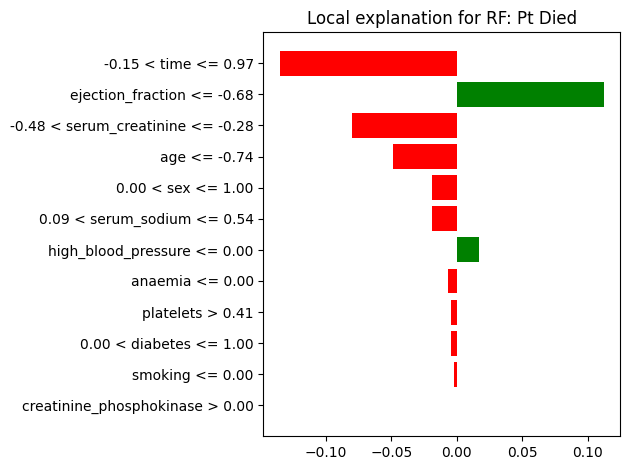

In [22]:
# Lime Explainer for Random Forest positive outcome (patient dies)
rf_exp_pos = lime_explainer.explain_instance(
    pos_row.values[0],
    rf_best.predict_proba,
    num_features=len(X_train.columns)
)
print("=== RF — Positive Sample ===")
print(f"Intercept  : {rf_exp_pos.intercept[1]:.4f}")
print(f"Coefficients (feature, weight):")
for feat, weight in rf_exp_pos.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")
print(f"R² of local linear model: {rf_exp_pos.score:.4f}")
rf_exp_pos.as_pyplot_figure(label=1)
plt.title("Local explanation for RF: Pt Died")
plt.tight_layout()
plt.show()

=== XGB — Negative Sample ===
Intercept  : 0.3039
Coefficients (feature, weight):
  serum_creatinine > 0.01                        +0.2192
  time > 0.97                                    -0.1858
  age > 0.73                                     +0.0719
  -0.01 < ejection_fraction <= 0.59              -0.0432
  platelets <= -0.52                             +0.0282
  -0.35 < creatinine_phosphokinase <= 0.00       +0.0230
  0.00 < smoking <= 1.00                         +0.0112
  0.00 < sex <= 1.00                             -0.0074
  anaemia <= 0.00                                -0.0061
  diabetes <= 0.00                               +0.0027
  -0.60 < serum_sodium <= 0.09                   +0.0017
  high_blood_pressure <= 0.00                    -0.0010
R² of local linear model: 0.2516


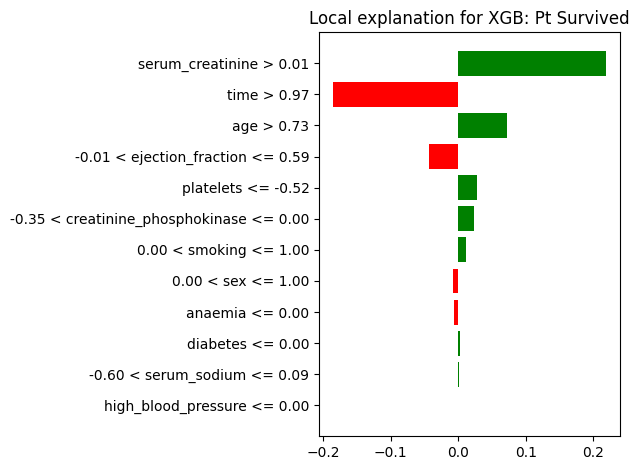

In [23]:
# Lime Explainer for XGBoost negative outcome (patient survives)
xgb_exp_neg = lime_explainer.explain_instance(
    neg_row.values[0],
    xg_best.predict_proba,
    num_features=len(X_train.columns)
)
print("=== XGB — Negative Sample ===")
print(f"Intercept  : {xgb_exp_neg.intercept[1]:.4f}")
print(f"Coefficients (feature, weight):")
for feat, weight in xgb_exp_neg.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")
print(f"R² of local linear model: {xgb_exp_neg.score:.4f}")
xgb_exp_neg.as_pyplot_figure(label=1)
plt.title("Local explanation for XGB: Pt Survived")
plt.tight_layout()
plt.show()

=== XGB — Positive Sample ===
Intercept  : 0.3821
Coefficients (feature, weight):
  -0.15 < time <= 0.97                           -0.1519
  ejection_fraction <= -0.68                     +0.0979
  -0.48 < serum_creatinine <= -0.28              -0.0659
  age <= -0.74                                   -0.0338
  0.09 < serum_sodium <= 0.54                    -0.0263
  creatinine_phosphokinase > 0.00                +0.0249
  platelets > 0.41                               -0.0180
  smoking <= 0.00                                -0.0090
  0.00 < diabetes <= 1.00                        +0.0065
  anaemia <= 0.00                                -0.0059
  0.00 < sex <= 1.00                             -0.0039
  high_blood_pressure <= 0.00                    -0.0028
R² of local linear model: 0.1163


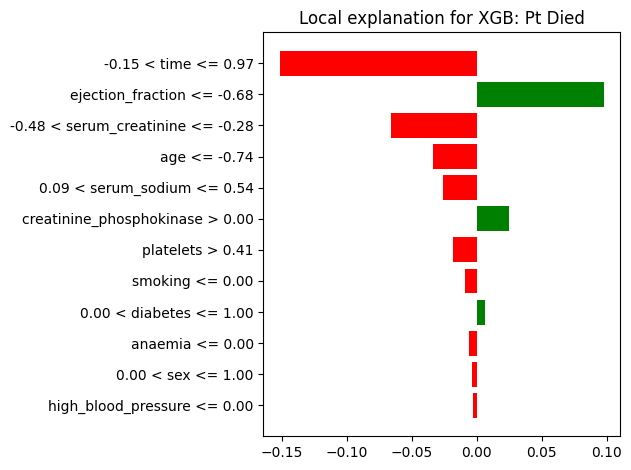

In [24]:
# Lime Explainer for XGBoost positive outcome (patient dies)
xgb_exp_pos = lime_explainer.explain_instance(
    pos_row.values[0],
    xg_best.predict_proba,
    num_features=len(X_train.columns)
)
print("=== XGB — Positive Sample ===")
print(f"Intercept  : {xgb_exp_pos.intercept[1]:.4f}")
print(f"Coefficients (feature, weight):")
for feat, weight in xgb_exp_pos.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")
print(f"R² of local linear model: {xgb_exp_pos.score:.4f}")
xgb_exp_pos.as_pyplot_figure(label=1)
plt.title("Local explanation for XGB: Pt Died")
plt.tight_layout()
plt.show()

LIME works by slightly varying the input values around a single patient and fitting a simple linear model to see which features mattered most locally for that prediction. All plots show feature contributions toward the Died (1) class (green bars push toward death, red bars push against it).

**RF - Patient Survival (R² = 0.28)**: This is a reasonable fit. The dominant feature was `serum_creatinine`, which pushed strongly toward death (+0.234). This patient had elevated creatinine despite surviving, which confused the model somewhat. `time` and `ejection_fraction` pushed back toward survival.

**RF - Patient Death (R² = 0.15)**: This is a low R². The local linear model does not capture the Random Forest's behavior well for this patient. `time` was the main feature, pushing against a death prediction despite this patient having died.

**XGBoost - Patient Survival (R² = 0.30)**: Another reasonable fit. Again `serum_creatinine` (+0.147) was the biggest push toward death, with `time` and `ejection_fraction` as protective factors.

**XGBoost - Patient Death (R² = 0.15)**: Low R² where `time` was again the main feature. The local linear model does not approximate XGBoost well for this patient.

SHAP for XGBoost instructions:
* Use SHAP library to interpret the XGBoost model. Specifically, call the TreeExplainer
method of SHAP, TreeExplainer is optimized for tree-based models.
* Visualize your explanations, one for positive and one for negative, using the 'force_plot'
function.
* Note: You need to establish a 'base value' to be used by 'force_plot'. The
explainer.expected_value is the 'base value'.
* Create the feature importance plot by calling SHAP's 'summary_plot' function, for each
class/label.

In [25]:
# Initialize TreeExplainer and get base value
shap.initjs()

shap_explainer = shap.TreeExplainer(xg_best)
shap_values = shap_explainer.shap_values(X_test)

base_value = shap_explainer.expected_value
print(f"Base value (expected_value): {base_value:.4f}")

Base value (expected_value): -0.8816


Force plot for NEGATIVE sample (true label = 0)


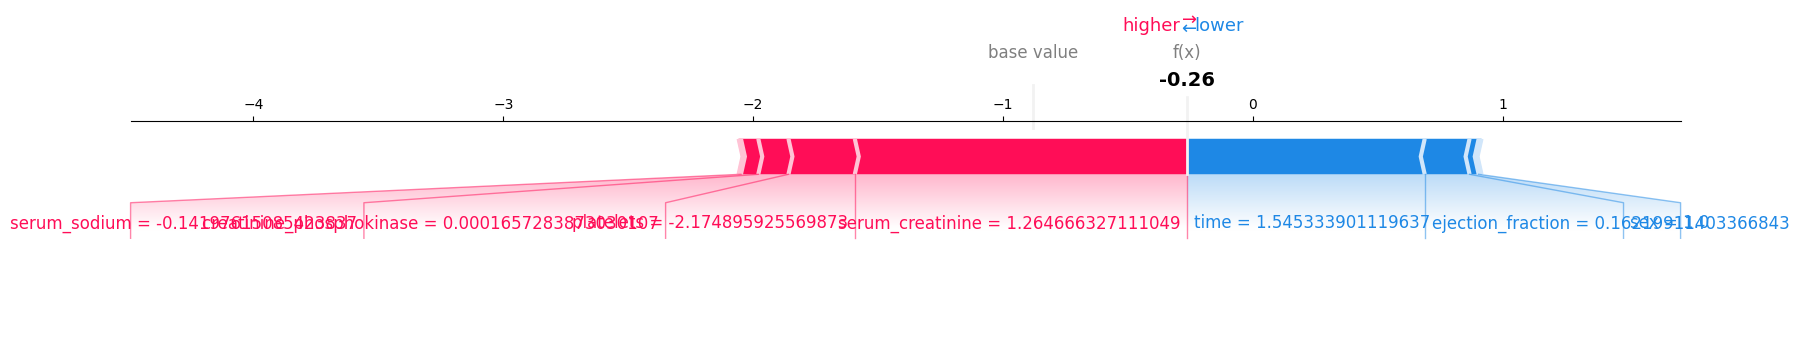

In [26]:
# Force plot for negative sample (patient lives)
print(f"Force plot for NEGATIVE sample (true label = {y_test[neg_idx]})")
shap.force_plot(
    base_value,
    shap_values[X_test.index.get_loc(neg_idx)],
    X_test.loc[neg_idx],
    matplotlib=True
)

Force plot for POSITIVE sample (true label = 1)


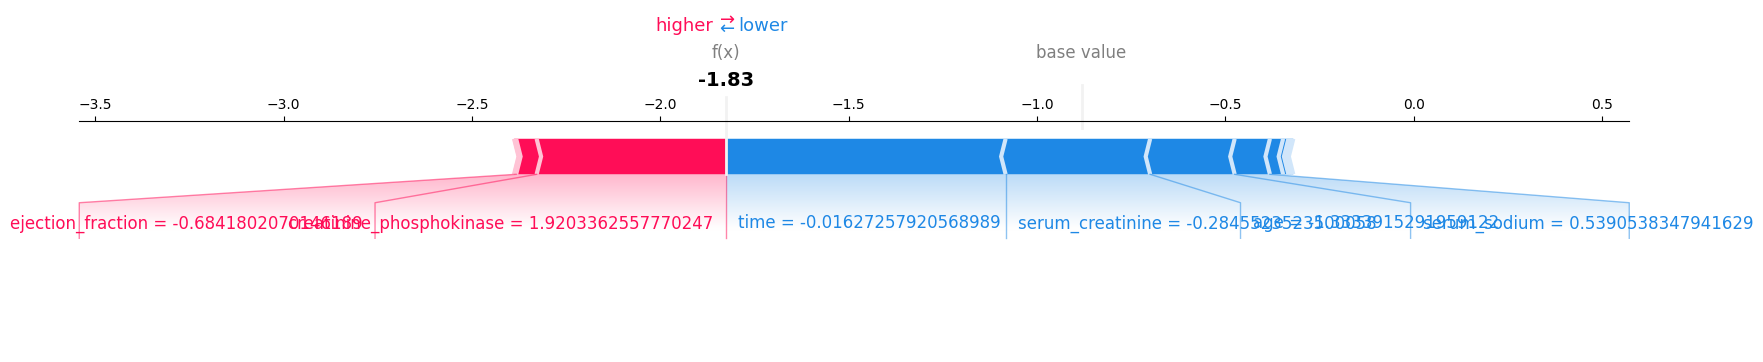

In [27]:
# Force plot for positive sample (patient dies)
print(f"Force plot for POSITIVE sample (true label = {y_test[pos_idx]})")
shap.force_plot(
    base_value,
    shap_values[X_test.index.get_loc(pos_idx)],
    X_test.loc[pos_idx],
    matplotlib=True
)

SHAP Summary Plot | Class 0 (Survived)


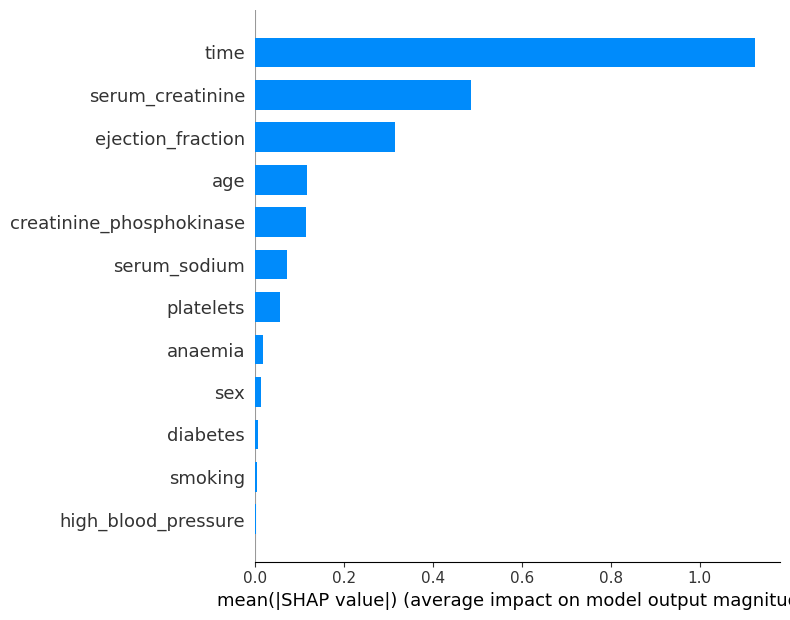

SHAP Summary Plot | Class 1 (Died)


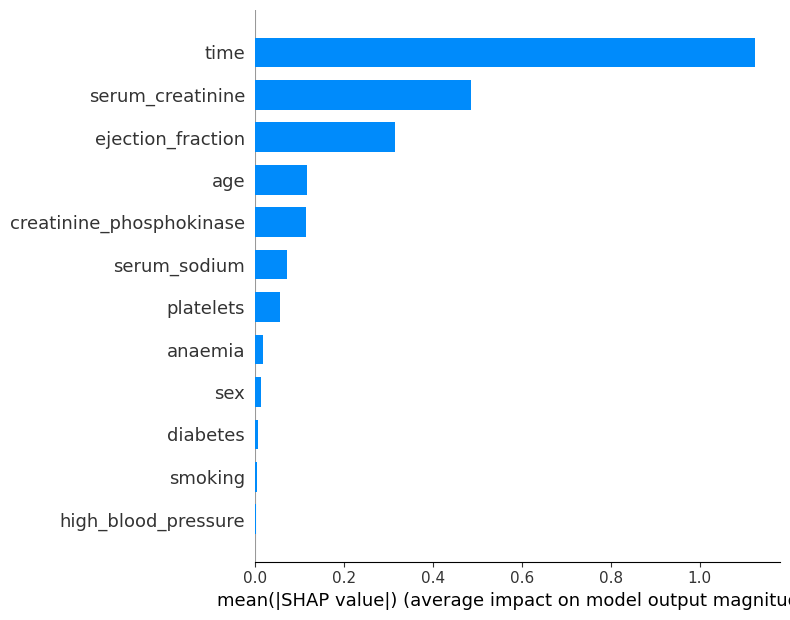

SHAP Summary Plot | Beeswarm (all classes)


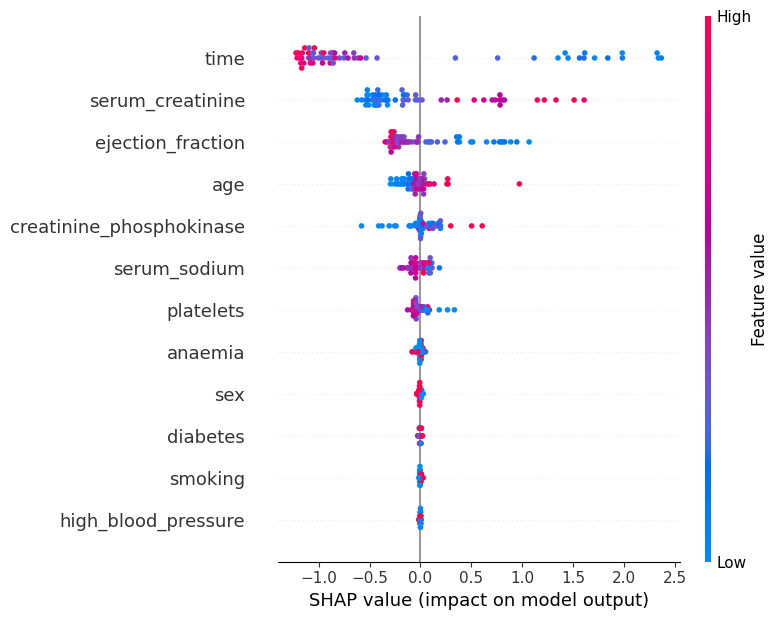

In [28]:
# SHAP Summary plot per class
shap_vals_2d = shap_explainer.shap_values(X_test)

print("SHAP Summary Plot | Class 0 (Survived)")
shap.summary_plot(-shap_vals_2d, X_test, plot_type="bar", show=True)

print("SHAP Summary Plot | Class 1 (Died)")
shap.summary_plot(shap_vals_2d, X_test, plot_type="bar", show=True)

# SHAP Summary of all Classes

print("SHAP Summary Plot | Beeswarm (all classes)")
shap.summary_plot(shap_values, X_test)

#### SHAP for XGBoost

The base value of -0.884 is the model's starting point before it looks at any individual patient's features. It reflects the overall rate of death in the training data which is a roughly 29% baseline probability of death.

**Patient Survival**: Despite this patient surviving, the SHAP values actually pushed the prediction above the base value, toward a higher death probability. The biggest driver was elevated `serum_creatinine` (+0.765), which strongly signaled death risk. `time` (-0.421) and `ejection_fraction` (-0.093) pushed back toward survival, but the creatinine signal dominated. This was a difficult case for the model.

**Patient Death**: Despite this patient dying, the SHAP values pushed the prediction below the base value, toward a lower death probability. A long `time` value (-0.407) was the biggest factor pushing toward survival. `creatinine_phosphokinase` (+0.229) pushed toward death, but `serum_creatinine` (-0.147) and `age` (-0.142) unexpectedly pushed toward survival. This was also a difficult case for the model.

**Overall feature importance**: Across all test patients, `serum_creatinine` and `time` are the two features that influence the model's predictions the most, followed by `ejection_fraction`, `platelets`, and `creatinine_phosphokinase`. `smoking`, `diabetes`, and `high_blood_pressure` contributed almost nothing to the model's decisions on this dataset.

4. Predict observations, one for positive and one for negative label, by using all four (4)
models and indicate which one gives the better prediction.
Provide output for showing the accuracy of each model as follows:
False/True label: 0/1 (or 0/1 depending on how you define labels)
* LR: [prob_T prob_F]
* DT: [prob_T prob_F]
* RF: [prob_T prob_F]
* XGB: [prob_T prob_F]

The above calculations are derived by calling the predict_proba method.
Note: predict_proba(X): Predict class probabilities for X.

In [29]:
# Iterate through models to predict patient outcome
models = {
    'LR' : lr_best,
    'DT' : dt_best,
    'RF' : rf_best,
    'XGB': xg_best,
}

for label_name, row, true_label in [
        ('NEGATIVE (true label = 0)', neg_row, y_test[neg_idx]),
        ('POSITIVE (true label = 1)', pos_row, y_test[pos_idx])
]:
    print(f"\n{'='*55}")
    print(f"Sample: {label_name}")
    print(f"{'='*55}")
    print(f"{'Model':<6}  {'P(Survived=0)':>15}  {'P(Died=1)':>12}  {'Predicted':>10}  {'Correct?':>8}")
    print("-"*55)
    for name, model in models.items():
        proba = model.predict_proba(row)[0]
        pred  = model.predict(row)[0]
        correct = '✓' if pred == true_label else '✗'
        print(f"{name:<6}  {proba[0]:>15.4f}  {proba[1]:>12.4f}  {pred:>10}  {correct:>8}")


Sample: NEGATIVE (true label = 0)
Model     P(Survived=0)     P(Died=1)   Predicted  Correct?
-------------------------------------------------------
LR               0.7483        0.2517           0         ✓
DT               0.0000        1.0000           1         ✗
RF               0.5182        0.4818           0         ✓
XGB              0.5652        0.4348           0         ✓

Sample: POSITIVE (true label = 1)
Model     P(Survived=0)     P(Died=1)   Predicted  Correct?
-------------------------------------------------------
LR               0.7543        0.2457           0         ✗
DT               1.0000        0.0000           0         ✗
RF               0.8783        0.1217           0         ✗
XGB              0.8613        0.1387           0         ✗


In [30]:
print(f"{'Model':<6}  {'Accuracy':>10} {'Precision':>10} {'AUC-ROC':>10}")
print("-"*40)
for name, model in models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    prec = precision_score(y_test, model.predict(X_test))
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name:<6}  {acc:>10.4f} {prec:>10.4f} {auc:>10.4f}")

Model     Accuracy  Precision    AUC-ROC
----------------------------------------
LR          0.6333     1.0000     0.8491
DT          0.7667     0.7895     0.8051
RF          0.7500     0.8571     0.8400
XGB         0.7500     0.8125     0.8469


**The four models perform competitively, with Logistic Regression edging out the ensembles on AUC-ROC.** The AUC-ROC ranking is LR (0.849), XGBoost (0.847), Random Forest (0.840), and Decision Tree (0.805), with the top three within 0.01 of each other. On accuracy, the tree-based models lead: Decision Tree (76.7%), Random Forest (75.0%), XGBoost (75.0%), Logistic Regression (63.3%).

Logistic Regression's accuracy looks low (63%), but its AUC-ROC of 0.849 shows that it ranks patients by risk just as well as the ensembles. The gap between its ranking quality and its threshold-based accuracy means the default 0.5 decision threshold is poorly placed, likely because of the heavy regularization (C=0.01) chosen during tuning. Its precision of 1.000 is striking, but on a test set this small (60 patients) it reflects that the model only flags patients it is very confident about, which is the same conservative behavior that drives the low accuracy.

The Decision Tree has the highest accuracy but the lowest AUC-ROC, meaning its probability estimates are less reliable than the ensemble models, even though its yes/no predictions happen to be correct more often on this particular test split.

Logistic Regression, Random Forest, and XGBoost all correctly predicted the negative sample, with only the Decision Tree missing it; all four models missed the positive sample. Given the closeness of the AUC scores and the small test set, no single model is decisively best for this task; **Random Forest and XGBoost are reasonable defaults** for their balance of accuracy and ranking quality, with Logistic Regression as a strong baseline that may benefit from threshold tuning before deployment.

Across the ELI5, LIME, and SHAP explanations, the most relevant features are consistently `serum_creatinine`, `time`, and `ejection_fraction`. Elevated serum creatinine suggests reduced kidney function, which the literature identifies as a comorbidity for heart failure mortality. Lower ejection fraction directly indicates weaker heart pumping function and is also a known predictor. The `time` feature (follow-up period in days) is the strongest predictor in the dataset, but it functions as a survival proxy rather than a clinical input: patients with shorter follow-up periods are more likely to have died during the study window. Surprisingly, smoking, anaemia, and diabetes appear to have minimal effects on the prediction across all models.

Based on these findings, an older patient with high serum creatinine and low ejection fraction is at the highest risk, and there is observable comorbidity between kidney dysfunction and heart failure.

In a future analysis, it would be interesting to re-run the models with `time` excluded, since its strength as a predictor partly reflects the structure of the study (length of observation) rather than a clinically actionable signal.